### 統計学と機械学習

統計学と機械学習は、データから知識を抽出するための方法論ですが、その目的、アプローチ、適用される技術において相違点がある。
統計学と機械学習は相互補完的であり、データ分析においてそれぞれ異なる視点とツールを提供する。実際の応用では、両方のアプローチを組み合わせ、より深い洞察を得る。
#### 目的と哲学
- 統計学：データを用いて仮説を検証し、推論を行う。結果の不確実性を評価し、モデルの解釈可能性を重視。

- 機械学習：データからパターンを学習し、予測を行う。特に、高い予測精度を達成することが目標であり、モデルの複雑さや解釈可能性が犠牲になることもある。

#### アプローチ
- 統計学：伝統的に小さなデータセットでの作業に適しており、モデルの背後にある理論的な仮定を重視。

- 機械学習：大量のデータを扱い、計算能力を利用して複雑なモデルを構築する。データ駆動アプローチであり、理論的な仮定よりも実験的な結果を重視する。

#### 技術とツール
- 統計学：線形回帰、ANOVA、確率論などの伝統的な統計的手法が一般的。

- 機械学習：決定木、ニューラルネットワーク、サポートベクターマシンなどのより複雑なアルゴリズムが使用される。

#### データの扱い:
- 統計学：データの品質、構造、そしてそれがモデルに与える影響について深く考慮。

- 機械学習：大量のデータを処理する能力があり、時にはデータの前処理やクリーニングに自動的なアプローチを取る。

### 過学習について
機械学習やAIの開発では、**過学習** という現象が嫌われる。
簡単にいえば、予測モデルが過去のデータに過剰に適合しすぎてしまって、未来にくるはずの新しいデータへの予測があまり正確にできなくなる現象。

>例：過去問ばかり繰り返し練習しても、本番の試験の問題は解けない。
>
>訓練データの過剰適合: 学生が過去の試験問題だけを繰り返し勉強して、その解答を完璧に覚えてしまった場合。
>    - 学生は過去の問題には非常に強くなりますが、単に問題と解答を暗記しているだけ。
>    - 実際の試験で全く新しい問題が出された場合、学生は問題を解くための基礎知識や原理を適用する方法を学んでいないため、うまく対応できない可能性がある。


説明変数: Index(['犯罪率', '緑地', '工場', '川近', '大気汚染', '部屋数', '築年', '通勤', '交通', '資産税', '教員比',
       '低所得率'],
      dtype='object') 次元: (506, 12)

MAE（平均絶対誤差）:  3.356306045529151
MSE（平均二乗誤差）:  22.429681439489933
R²（決定係数）: 0.7343070437613075

重回帰モデルが、データの 約73.43% を説明できている。


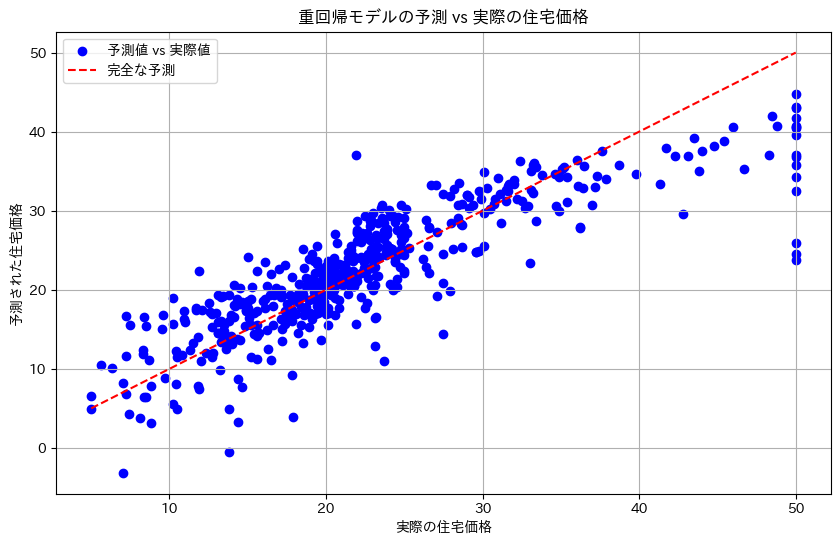

In [54]:
# 重回帰分析（住宅価格以外の全てを説明変数に設定）
# 過学習が発生しているかどうかは分からない。

import pandas as pd
import matplotlib.pyplot as plt
import japanize_matplotlib # matplotlibの日本語化
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

df = pd.read_csv('./data/boston_dropped_bias.csv')

df.head()



# データの準備
X = df[df.columns[:-1]]  # 住宅価格以外の全てを説明変数に設定
y = df['住宅価格']  # 目的変数

# モデルの構築
model = LinearRegression()
model.fit(X, y)

# 予測値の計算
y_pred = model.predict(X)

# 結果の表示
print('説明変数:', X.columns, '次元:', X.shape)
print("\nMAE（平均絶対誤差）: ", mean_absolute_error(y, y_pred))
print("MSE（平均二乗誤差）: ", mean_squared_error(y, y_pred))
print('R²（決定係数）:', r2_score(y, y_pred))
print(f"\n重回帰モデルが、データの 約{r2_score(y, y_pred) * 100:.2f}% を説明できている。")


# 重回帰モデルのグラフ
plt.figure(figsize=(10, 6))
plt.scatter(y, y_pred, color='blue', label='予測値 vs 実際値')
plt.plot([y.min(), y.max()], [y.min(), y.max()], color='red', linestyle='--', label='完全な予測')
plt.xlabel('実際の住宅価格')
plt.ylabel('予測された住宅価格')
plt.title('重回帰モデルの予測 vs 実際の住宅価格')
plt.legend()
plt.grid()
plt.show()

### ホールドアウト法
ホールドアウト法(holdout)は、機械学習モデルの性能評価と過学習の検出に使われるシンプルな手法。

この方法では、利用可能なデータセットを二つの部分に分割する。
- 一つはモデルの訓練に使用する「**訓練セット**」(モデルを学習するためのデータ)
- 一つはモデルの評価に使用する「**テストセット**」(モデルを評価するためのデータ)

**ホールドアウト法の手順**
1. **データセットの分割** : 全データセットをランダムに二つに分割。一般的には、70%のデータを訓練セット、残りの30%をテストセットとして保持する。(プロジェクトの要件に応じて調整される)。
2. **モデルの訓練** : 訓練セットを使用してモデルを訓練する。
3. **モデルの評価** : 訓練されたモデルをテストセットに適用し、その性能を評価。

データセットの分割

### データセットの分割
**`sklearn`** には、ランダムにデータを訓練データとテストデータに分割する関数`train_test_split()`がある。

- `test_size` : 訓練用(70%),テスト用(30%)
- `random_state=0` : 乱数の生成を固定し、毎回同じ乱数で分割させる

In [35]:
# ホールドアウト法
import pandas as pd
import matplotlib.pyplot as plt
import japanize_matplotlib # matplotlibの日本語化
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split # データセットの分割に必要な関数をインポート

df = pd.read_csv('./data/boston_dropped_bias.csv')

# データの準備
X = df[df.columns[:-1]]  # 住宅価格以外の全てを説明変数に設定
y = df['住宅価格']  # 目的変数

# データセットの分割 (訓練データとテストデータに分割)
# test_size=0.3 は、データの30%をテストデータに使用することを意味する。
# random_state=0 は、データの分割を再現可能にするための乱数シードを設定する。
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)

print('== データセットの分割 ==')
print('訓練データ数:', len(X_train))
print('テストデータ数:', len(X_test))

# モデルの構築
model = LinearRegression()
# 訓練データを使ってモデルを学習させる。
model.fit(X_train, y_train)

# テストデータを使って予測値を計算する。
y_pred = model.predict(X_test)
# 結果の表示
print("\n== モデルの評価 ==")
print("テストデータ MAE（平均絶対誤差）: ", mean_absolute_error(y_test, y_pred))
print("テストデータ MSE（平均二乗誤差）: ", mean_squared_error(y_test, y_pred))
print('テストデータ R²（決定係数）:', r2_score(y_test, y_pred))
print(f"\n重回帰モデルが、テストデータの 約{r2_score(y_test, y_pred) * 100:.2f}% を説明できている。")


# 過学習のチェック
# 訓練データに対する予測値を計算する。
y_train_pred = model.predict(X_train)
print("\n== 過学習のチェック ==")
print("訓練データ MAE（平均絶対誤差）: ", mean_absolute_error(y_train, y_train_pred))
print("訓練データ MSE（平均二乗誤差）: ", mean_squared_error(y_train, y_train_pred))
print('訓練データ R²（決定係数）:', r2_score(y_train, y_train_pred))
print(f"\n重回帰モデルが、訓練データの 約{r2_score(y_train, y_train_pred) * 100:.2f}% を説明できている。")
print("\nテストデータに対する説明力と比較して、訓練データに対する説明力が明らかに高い場合は、過学習の可能性がある。")
print("今回のモデルでは、明らかに訓練データのスコアが高く、過学習を疑うべき状況にある。")


== データセットの分割 ==
訓練データ数: 354
テストデータ数: 152

== モデルの評価 ==
テストデータ MAE（平均絶対誤差）:  3.7032920391803303
テストデータ MSE（平均二乗誤差）:  28.146790268541157
テストデータ R^2（決定係数）: 0.6619633616256452

重回帰モデルが、テストデータの 約66.20% を説明できている。

== 過学習のチェック ==
訓練データ MAE（平均絶対誤差）:  3.1828517232075306
訓練データ MSE（平均二乗誤差）:  20.216965685486308
訓練データ R^2（決定係数）: 0.7614925768121829

重回帰モデルが、訓練データの 約76.15% を説明できている。

テストデータに対する説明力と比較して、訓練データに対する説明力が明らかに高い場合は、過学習の可能性がある。
今回のモデルでは、明らかに訓練データのスコアが高く、過学習を疑うべき状況にある。


### 過学習の対策
過学習を防ぐためのアプローチには、統計学と機械学習のの根底にある哲学と実践方法の違いが反映される。具体的な戦略やモデル選択においても明確に現れる。

**統計学のアプローチ**

- **理論的背景** : モデルの複雑さを抑えることで過学習を防ぐ方法を重視。モデルの選択やパラメータの推定においては、理論に基づいた厳格な手法が用いられる。
- **正則化と情報基準** : 過学習を避けるために正則化技術（例: リッジ回帰、ラッソ回帰）を使用。また、AIC（赤池情報量基準）やBIC（ベイズ情報量基準）のような情報基準を用いて、モデルの複雑さとデータへの適合度をトレードオフする。
- **解釈可能性の重視** : モデルの解釈可能性が非常に重要視。そのため、よりシンプルなモデルが好まれ、過学習のリスクを低減する。

**機械学習のアプローチ**

- **データ駆動** : 大量のデータを利用してモデルを学習させることに焦点を置く。過学習を防ぐために、データセットを訓練セット、検証セット、テストセットに分割するなどの手法が一般的。
- **クロスバリデーション** : データのランダムな部分集合を用いてモデルを評価し、その平均性能を基にモデルを選択。これにより、モデルが未知のデータに対しても一般化する能力を持つかを確認。
- **ハイパーパラメータの調整** : ハイパーパラメータのチューニングにより過学習を制御することが多い。理論的な分析より、グリッドサーチやランダムサーチ、ベイジアン最適化などの手法が用いる。

### 交差検証(CV：クロスバリデーション)
1. データをまずK個に分割して、そのうちひとつだけををテストデータ、残りを訓練データとして学習・評価。
2. ２回目以降は、テストデータを切り替えてk回評価する。
3. 最後に、各回で測定したスコアの平均でモデルの評価をする方法

`sklearn` では、`cross_val_score` として関数が用意されている。

### 交差検証（Cross Validation）のイメージ

| 回数 | データ分割の状態 | スコア |
| :--- | :--- | :--- |
| **1回目** | <span style="background-color:#777; color:white; padding:2px 20px;">学習</span><span style="background-color:#777; color:white; padding:2px 20px;">学習</span><span style="background-color:#777; color:white; padding:2px 20px;">学習</span><span style="background-color:#777; color:white; padding:2px 20px;">学習</span><span style="background-color:#d48806; color:white; padding:2px 20px;">検証</span> | スコア1 |
| **2回目** | <span style="background-color:#777; color:white; padding:2px 20px;">学習</span><span style="background-color:#777; color:white; padding:2px 20px;">学習</span><span style="background-color:#777; color:white; padding:2px 20px;">学習</span><span style="background-color:#d48806; color:white; padding:2px 20px;">検証</span><span style="background-color:#777; color:white; padding:2px 20px;">学習</span> | スコア2 |
| **3回目** | <span style="background-color:#777; color:white; padding:2px 20px;">学習</span><span style="background-color:#777; color:white; padding:2px 20px;">学習</span><span style="background-color:#d48806; color:white; padding:2px 20px;">検証</span><span style="background-color:#777; color:white; padding:2px 20px;">学習</span><span style="background-color:#777; color:white; padding:2px 20px;">学習</span> | スコア3 |
| **4回目** | <span style="background-color:#777; color:white; padding:2px 20px;">学習</span><span style="background-color:#d48806; color:white; padding:2px 20px;">検証</span><span style="background-color:#777; color:white; padding:2px 20px;">学習</span><span style="background-color:#777; color:white; padding:2px 20px;">学習</span><span style="background-color:#777; color:white; padding:2px 20px;">学習</span> | スコア4 |
| **5回目** | <span style="background-color:#d48806; color:white; padding:2px 20px;">検証</span><span style="background-color:#777; color:white; padding:2px 20px;">学習</span><span style="background-color:#777; color:white; padding:2px 20px;">学習</span><span style="background-color:#777; color:white; padding:2px 20px;">学習</span><span style="background-color:#777; color:white; padding:2px 20px;">学習</span> | スコア5 |
| | | <span style="color:red; font-weight:bold;">平均スコア</span> |

== 交差検証の結果 ==
R^2（決定係数）: [0.72075041 0.78838422 0.57369019 0.70672655 0.73035169]

交差検証の平均 R²（決定係数）: 0.7040


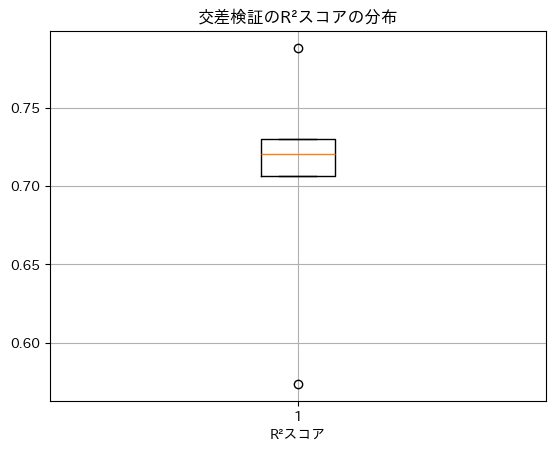

In [53]:
# 交差検証


import pandas as pd
import matplotlib.pyplot as plt
import japanize_matplotlib # matplotlibの日本語化
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split # データセットの分割に必要な関数をインポート
from sklearn.model_selection import cross_validate, cross_val_score


df = pd.read_csv('./data/boston_dropped_bias.csv')

# データの準備
df = df.sample(500) #500個ほどサンプリング
X = df[df.columns[:-1]]  # 住宅価格以外の全てを説明変数に設定
y = df['住宅価格']  # 目的変数

scores = cross_val_score(LinearRegression(), X, y, cv=5, scoring='r2')

print('== 交差検証の結果 ==')
print('R^2（決定係数）:', scores)

# 交差検証の平均スコアを表示
print(f"\n交差検証の平均 R²（決定係数）: {scores.mean():.4f}")


# boxplot でスコアの分布を確認
plt.boxplot(scores, vert=True )
plt.title('交差検証のR²スコアの分布')
plt.xlabel('R²スコア')
plt.grid()
plt.show()



### 正則化
正則化技術は、機械学習モデルの過学習を防ぐために使用される手法。

具体的には、モデルの複雑さにペナルティを課すことで、モデルが訓練データのノイズや無関係なパターンを学習しすぎるのを防ぐ。

**正則化の主な手法**

1. **L1正則化（ラッソ回帰）** : モデルの係数の絶対値の和に比例するペナルティがコスト関数に追加される。L1正則化はいくつかの係数を完全にゼロにすることがあり、これによりモデルがよりシンプルになり、解釈しやすくなる場合がある（特徴選択の効果もあります）。

2. **L2正則化（リッジ回帰）** : 係数の二乗の和に比例するペナルティがコスト関数に追加される。これは、大きな係数に対してより大きなペナルティを課し、モデルの係数を小さく保つことで過学習を防ぐ。L2正則化は、係数を完全にゼロにはしないが、モデルの予測性能を改善するのに役立つ。

3. **弾性ネット** : 弾性ネットはL1とL2の両方の正則化を組み合わせたもので、モデルの係数に対してL1正則化とL2正則化の両方のペナルティを同時に適用する。これにより、ラッソ回帰とリッジ回帰の両方の利点を活かすことができる。


正則化を使用すると、モデルは重要な特徴に焦点を当て、無関係な特徴による過剰な適合を避けることができる。
- L1正則化（ラッソ回帰）を適用すると、不要な特徴の係数がゼロになり、モデルがシンプルになる。
- L2正則化（リッジ回帰）を適用すると、すべての特徴の影響が均等に抑えられ、過剰な適合を防ぐことができる。

正則化により、モデルは訓練データに含まれる本質的なパターンを学習し、未知のデータに対しても一般化する能力を高めることができます。

### ラッソ回帰
ラッソ回帰モデルを使用するときは、
`scikit-learn`ライブラリを利用して、`LinearRegression`の代わりに`Lasso`クラスをインポート。

>**ハイパーパラメータとは**
>
>機械学習アルゴリズムやモデルの学習プロセスを制御するために設定されるパラメータ。これらはモデルの学習前に設定され、訓練データからは学習されない。
>
>ハイパーパラメータは、モデルの性能に大きく影響を与えるため、適切な値を見つけるために調整が必要。グリッドサーチやランダムサーチ、ベイズ最適化などの手法を使用して最適なハイパーパラメータを見つけることが一般的。
>
>リッジ回帰やラッソ回帰のalphaパラメータは、正則化の強さを制御し、モデルの複雑さを調整する。

In [85]:
# ラッソ回帰


import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_validate, cross_val_score
from sklearn.linear_model import Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline


df = pd.read_csv('./data/boston_dropped_bias.csv')

# データの準備
df = df.sample(500) #500個ほどサンプリング
X = df[df.columns[:-1]]  # 住宅価格以外の全てを説明変数に設定
y = df['住宅価格']  # 目的変数

# ラッソ回帰モデルの構築
model = make_pipeline(
    StandardScaler(), #特徴量のスケーリングを行うための前処理ステップ。StandardScalerは、各特徴量を平均0、標準偏差1に変換する。
    Lasso(
        alpha=0.5, #正則化の強さを制御するパラメータ。値が大きいほど、モデルの複雑さが減少し、過学習のリスクが減る。
        max_iter=2000, #反復の最大数。モデルが収束するまでの最大反復回数を指定する。収束しない場合は、警告が表示される。
        tol=1e-4, #収束の許容誤差。モデルが収束したとみなすための基準を指定する。値が小さいほど、より厳密な収束が求められる。
        fit_intercept=True, #切片を計算するかどうかを指定する。Trueの場合、切片が計算される。
        precompute=True, #計算の高速化のために、事前に計算された行列を使用するかどうかを指定する。Trueの場合、事前に計算された行列が使用される。
        positive=False, #回帰係数を正の値に制限するかどうかを指定する。Trueの場合、回帰係数は正の値に制限される。
        selection='random', #特徴量の選択方法を指定する。'random'は、ランダムに特徴量を選択する方法。
        random_state=0 #乱数シードを設定することで、モデルの結果を再現可能にする。
    )
)

# 交差検証でモデルの評価
scores = cross_val_score(model, X, y, cv=5, scoring='r2')

print('== ラッソ回帰の交差検証の結果 ==')
print('R²（決定係数）:', scores)
print(f"\nラッソ回帰の交差検証の平均 R²（決定係数）: {scores.mean():.4f}")



== ラッソ回帰の交差検証の結果 ==
R²（決定係数）: [0.61015761 0.65415929 0.73866741 0.5670378  0.71152873]

ラッソ回帰の交差検証の平均 R²（決定係数）: 0.6563


In [86]:
# リッジ回帰


import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_validate, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import Ridge



df = pd.read_csv('./data/boston_dropped_bias.csv')

# データの準備
df = df.sample(500) #500個ほどサンプリング
X = df[df.columns[:-1]]  # 住宅価格以外の全てを説明変数に設定
y = df['住宅価格']  # 目的変数

# リッジ回帰モデルの構築
model = make_pipeline(
    StandardScaler(), #特徴量のスケーリングを行うための前処理ステップ。StandardScalerは、各特徴量を平均0、標準偏差1に変換する。
    Ridge(
        alpha=0.5, #正則化の強さを制御するパラメータ。値が大きいほど、モデルの複雑さが減少し、過学習のリスクが減る。
        max_iter=2000, #反復の最大数。モデルが収束するまでの最大反復回数を指定する。収束しない場合は、警告が表示される。
        tol=1e-4, #収束の許容誤差。モデルが収束したとみなすための基準を指定する。値が小さいほど、より厳密な収束が求められる。
        fit_intercept=True, #切片を計算するかどうかを指定する。Trueの場合、切片が計算される。
        positive=False, #回帰係数を正の値に制限するかどうかを指定する。Trueの場合、回帰係数は正の値に制限される。
        random_state=0 #乱数シードを設定することで、モデルの結果を再現可能にする。
    )
)

# 交差検証でモデルの評価
scores = cross_val_score(model, X, y, cv=5, scoring='r2')

print('== リッジ回帰の交差検証の結果 ==')
print('R²（決定係数）:', scores)
print(f"\nリッジ回帰の交差検証の平均 R²（決定係数）: {scores.mean():.4f}")


== リッジ回帰の交差検証の結果 ==
R²（決定係数）: [0.75050118 0.78756426 0.69057557 0.61822682 0.68750586]

リッジ回帰の交差検証の平均 R²（決定係数）: 0.7069


### その他の回帰モデル
### 線形回帰(Linear Regression)
線形回帰は、最も基本的な回帰モデルの一つで、特徴量と目標値の間の線形関係を仮定する。

In [110]:
# 線形回帰
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_validate, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LinearRegression

df = pd.read_csv('./data/boston_dropped_bias.csv')

# データの準備
df = df.sample(500) #500個ほどサンプリング
X = df[df.columns[:-1]]  # 住宅価格以外の全てを説明変数に設定
y = df['住宅価格']  # 目的変数


# 線形回帰モデルの構築
model = make_pipeline(
    StandardScaler(), #特徴量のスケーリングを行うための前処理ステップ。StandardScalerは、各特徴量を平均0、標準偏差1に変換する。
    LinearRegression() #線形回帰モデルを構築するためのステップ。LinearRegressionは、単純な線形回帰モデルを使用する。
)


# 交差検証でモデルの評価
scores = cross_val_score(model, X, y, cv=5, scoring='r2')
print('== 線形回帰の交差検証の結果 ==')
print('R²（決定係数）:', scores)
print(f"\n線形回帰の交差検証の平均 R²（決定係数）: {scores.mean():.4f}")


== 線形回帰の交差検証の結果 ==
R²（決定係数）: [0.74825575 0.69690442 0.68805518 0.77339443 0.47317299]

線形回帰の交差検証の平均 R²（決定係数）: 0.6760


###  サポートベクター回帰 (Support Vector Regression, SVR)
SVRは、サポートベクターマシンを用いた回帰モデルで、線形および非線形の回帰問題に対応可能。

In [ ]:
# サポートベクター回帰
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_validate, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR

df = pd.read_csv('./data/boston_dropped_bias.csv')

# データの準備
df = df.sample(500) #500個ほどサンプリング
X = df[df.columns[:-1]]  # 住宅価格以外の全てを説明変数に設定
y = df['住宅価格']  # 目的変数

# サポートベクター回帰モデルの構築
model = make_pipeline(
    StandardScaler(), #特徴量のスケーリングを行うための前処理ステップ。StandardScalerは、各特徴量を平均0、標準偏差1に変換する。
    SVR(
        kernel='rbf', #カーネル関数を指定するパラメータ。'rbf'は、非線形な関係をモデル化するためのガウシアンカーネルを使用することを意味する。
        C=1.0, #誤差の許容度を制御するパラメータ。値が大きいほど、誤差を許容しないモデルになる。
        epsilon=0.1 #回帰の許容誤差を指定するパラメータ。値が小さいほど、より厳密な回帰が求められる。
        )
)



# 交差検証でモデルの評価
scores = cross_val_score(model, X, y, cv=5, scoring='r2')
print('== サポートベクター回帰の交差検証の結果 ==')
print('R²（決定係数）:', scores)
print(f"\nサポートベクター回帰の交差検証の平均 R²（決定係数）: {scores.mean():.4f}")



== サポートベクター回帰の交差検証の結果 ==
R²（決定係数）: [0.71273374 0.64193006 0.7045002  0.55469979 0.66052035]

サポートベクター回帰の交差検証の平均 R²（決定係数）: 0.6549


### 決定木回帰 (Decision Tree Regression)
決定木回帰は、データを分割して予測を行う非線形回帰モデル。単純で理解しやすいが、過学習しやすい欠点がある。

In [ ]:
# 決定木回帰
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_validate, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.tree import DecisionTreeRegressor


df = pd.read_csv('./data/boston_dropped_bias.csv')

# データの準備
df = df.sample(500) #500個ほどサンプリング
X = df[df.columns[:-1]]  # 住宅価格以外の全てを説明変数に設定
y = df['住宅価格']  # 目的変数

# 決定木回帰モデルの構築
model = make_pipeline(
    StandardScaler(), #特徴量のスケーリングを行うための前処理ステップ。StandardScalerは、各特徴量を平均0、標準偏差1に変換する。
    DecisionTreeRegressor(random_state=0) #決定木回帰モデルを構築するためのステップ。DecisionTreeRegressorは、非線形な関係を捉えることができる決定木ベースの回帰モデル。
)

# 交差検証でモデルの評価
scores = cross_val_score(model, X, y, cv=5, scoring='r2')
print('== 決定木回帰の交差検証の結果 ==')
print('R²（決定係数）:', scores)
print(f"\n決定木回帰の交差検証の平均 R²（決定係数）: {scores.mean():.4f}")


== 決定木回帰の交差検証の結果 ==
R²（決定係数）: [0.44326102 0.80104934 0.77010396 0.84901123 0.85512509]

決定木回帰の交差検証の平均 R²（決定係数）: 0.7437


### k近傍法回帰 (K-Nearest Neighbors Regression, KNN)
KNN回帰は、データの近傍にあるk個のサンプルの平均値を使って予測を行う非パラメトリック手法。単純で効果的な方法だが、計算コストが高くなることがある

In [127]:
# K近傍回帰
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_validate, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.neighbors import KNeighborsRegressor


df = pd.read_csv('./data/boston_dropped_bias.csv')

# データの準備
df = df.sample(500) #500個ほどサンプリング
X = df[df.columns[:-1]]  # 住宅価格以外の全てを説明変数に設定
y = df['住宅価格']  # 目的変数

# K近傍回帰モデルの構築
model = make_pipeline(
    StandardScaler(), #特徴量のスケーリングを行うための前処理ステップ。StandardScalerは、各特徴量を平均0、標準偏差1に変換する。
    KNeighborsRegressor(n_neighbors=5) #K近傍回帰モデルを構築するためのステップ。KNeighborsRegressorは、近傍のデータポイントを使用して予測を行う回帰モデル。
)

# 交差検証でモデルの評価
scores = cross_val_score(model, X, y, cv=5, scoring='r2')
print('== K近傍回帰の交差検証の結果 ==')
print('R²（決定係数）:', scores)
print(f"\nK近傍回帰の交差検証の平均 R²（決定係数）: {scores.mean():.4f}")

== K近傍回帰の交差検証の結果 ==
R²（決定係数）: [0.74407519 0.73254561 0.85706593 0.73872569 0.74345856]

K近傍回帰の交差検証の平均 R²（決定係数）: 0.7632


### ランダムフォレスト回帰 (Random Forest Regression)
ランダムフォレスト回帰は、複数の決定木を使って予測を行うアンサンブル学習の一種。過学習を防ぎ、精度の高い予測が可能。

In [ ]:
# ランダムフォレスト回帰
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_validate, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.ensemble import RandomForestRegressor

df = pd.read_csv('./data/boston_dropped_bias.csv')

# データの準備
df = df.sample(500) #500個ほどサンプリング
X = df[df.columns[:-1]]  # 住宅価格以外の全てを説明変数に設定
y = df['住宅価格']  # 目的変数

# ランダムフォレスト回帰モデルの構築
model = make_pipeline(
    StandardScaler(), #特徴量のスケーリングを行うための前処理ステップ。StandardScalerは、各特徴量を平均0、標準偏差1に変換する。
    RandomForestRegressor(
        n_estimators=100, #ランダムフォレスト内の決定木の数を指定するパラメータ。値が大きいほど、モデルの性能が向上する可能性があるが、計算コストも増加する。
        random_state=0 #乱数シードを設定することで、モデルの結果を再現可能にする。
        )
)

# 交差検証でモデルの評価
scores = cross_val_score(model, X, y, cv=5, scoring='r2')
print('== ランダムフォレスト回帰の交差検証の結果 ==')
print('R²（決定係数）:', scores)
print(f"\nランダムフォレスト回帰の交差検証の平均 R²（決定係数）: {scores.mean():.4f}")

== ランダムフォレスト回帰の交差検証の結果 ==
R²（決定係数）: [0.90084329 0.84388393 0.7252403  0.85564519 0.87788547]

ランダムフォレスト回帰の交差検証の平均 R²（決定係数）: 0.8407


### MLP回帰 (Multi-layer Perceptron Regression)
MLP回帰は、ニューラルネットワークを使用した回帰モデルで、多層パーセプトロン（MLP）を利用する。

In [ ]:
# MLP回帰
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_validate, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.neural_network import MLPRegressor

df = pd.read_csv('./data/boston_dropped_bias.csv')

# データの準備
df = df.sample(500) #500個ほどサンプリング
X = df[df.columns[:-1]]  # 住宅価格以外の全てを説明変数に設定
y = df['住宅価格']  # 目的変数

# MLP回帰モデルの構築
model = make_pipeline(
    StandardScaler(), #特徴量のスケーリングを行うための前処理ステップ。StandardScalerは、各特徴量を平均0、標準偏差1に変換する。
    MLPRegressor(
        hidden_layer_sizes=(100,50), #隠れ層の構造を指定するパラメータ。ここでは、1つ目の隠れ層に100ユニット、2つ目の隠れ層に50ユニットを持つ構造を指定している。
        max_iter=3000, #反復の最大数。モデルが収束するまでの最大反復回数を指定する。収束しない場合は、警告が表示される。
        early_stopping=True, #早期停止を有効にするかどうかを指定する。Trueの場合、検証スコアが改善しなくなったときにトレーニングが停止される。
        random_state=0, #乱数シードを設定することで、モデルの結果を再現可能にする。
        )
)

# 交差検証でモデルの評価
scores = cross_val_score(model, X, y, cv=5, scoring='r2')
print('== MLP回帰の交差検証の結果 ==')
print('R²（決定係数）:', scores)
print(f"\nMLP回帰の交差検証の平均 R²（決定係数）: {scores.mean():.4f}")



== MLP回帰の交差検証の結果 ==
R²（決定係数）: [0.84598658 0.85688543 0.80770266 0.86266037 0.77218521]

MLP回帰の交差検証の平均 R²（決定係数）: 0.8291
